### kNN Regressor으로 50cm 생선의 무게

In [2]:
import numpy as np

fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [3]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state=42,
        # stratify=fish_weight : regressor는 stratify를 사용하지 않음
    )

In [4]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1,1)

In [5]:
test_input = test_input.reshape(-1, 1)

#### kNN Regression Model

In [6]:
from sklearn.neighbors import KNeighborsRegressor

In [7]:
# 이웃의 갯수를 3으로 선택
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
#### 길이가 50cm인 생선의 무게를 예측
knr.predict([[50]])

array([1033.33333333])

#### 기존 데이터로 무게 확인

In [13]:
for i, v in list(enumerate(train_target)):
    if v == train_target.max():
        print(train_input[i], v)

[43.] 1100.0
[42.] 1100.0


> 기존 데이터에서는 길이가 42, 43cm인 경우에 무게가 1.1kg이 나왔는데, 50cm인 경우에 1kg이 좀 넘게 나왔다?

#### 산점도로 이웃을 구해서 확인해보자

In [14]:
import matplotlib.pyplot as plt

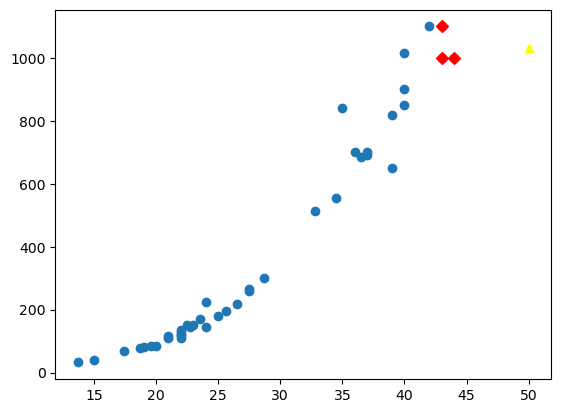

In [19]:
# 50cm인 생선의 이웃을 찾자
distance, indexes = knr.kneighbors([[50]])

# 훈련 세트의 산점도
plt.Figure(figsize=(10, 5))

plt.scatter(
    train_input,
    train_target
)

# 이웃
plt.scatter(
    train_input[indexes],
    train_target[indexes],
    marker='D',
    c='red'
)

# 50cm 위치
plt.scatter(
    50,
    1033,
    marker='^',
    c='yellow'
)

plt.show()

In [20]:
# 이웃들의 평균값 계산
np.mean(train_target[indexes])

np.float64(1033.3333333333333)

#### 길이가 100cm인 생선의 무게 예측

In [21]:
# 길이가 100cm인 생선의 무게
knr.predict([[100]])

array([1033.33333333])

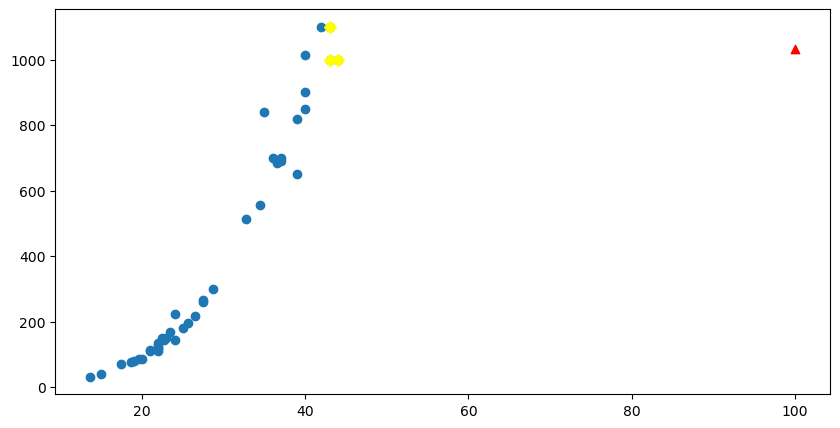

In [22]:
distance, indexes = knr.kneighbors([[100]])
plt.figure(figsize=(10, 5))
plt.scatter(
    train_input,
    train_target
)

plt.scatter(
    train_input[indexes],
    train_target[indexes],
    marker='D',
    c='yellow'
)

plt.scatter(
    100,
    1033,
    marker='^',
    c='red'
)

plt.show()

> kNN Regression은 주변 이웃의 값들의 평균을 구하는 것이므로, 학습한 데이터의 범위를 벗어나면 사용할 수 없다

----
#### 선형회귀 (Linear Regression)
: 직선이나 곡선의 함수식(방정식: y=ax+b)을 이용하여 구하는 방식으로 로지스틱 회귀분석이나 인공신경망의 기초가 되었다.

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
# Model
lr = LinearRegression()

In [25]:
lr.fit(train_input, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# 50cm 생선의 무게에 대한 예측
lr.predict([[50]])

array([1241.83860323])

In [27]:
# y = ax + b에서 기울기와 절편 출력(Deep Learning, 기울기 : weight, 절편 : Bias 라고 함)
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


In [28]:
print(39.01714496 * 50 -709.0186449535477)

1241.8386030464526


#### 산점도 그려보기

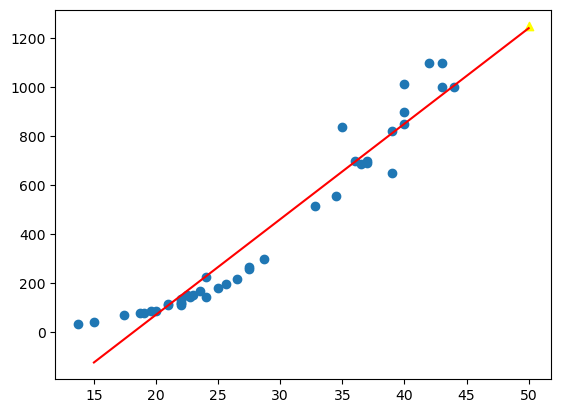

In [32]:
# 훈련세트의 산점도
plt.Figure(figsize=(10, 5))

plt.scatter(
    train_input,
    train_target
)
# 길이가 15 ~ 50cm 까지 1차방정식 그래프
plt.plot(
    [15, 50],
    [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_],
    c='red'
)
# 50cm 생선
plt.scatter(
    50,
    1248.8,
    marker='^',
    c='yellow'
)

plt.show()

> 산점도의 회귀선을 보니 길이가 작아졌을 때, 무게의 음수가 발생할 수 있다 + 절편이 음수다

#### 

----
#### 특성공학(Feature Engineering)
##### 다항회귀
- Y = aX + b -> Y = aX^2 + bX + c
##### 다중회귀 ()
- Y = aX1 + aX2 + ... + b

In [33]:
# Feature를 제곱한 Column을 생성하여 기존의 Column에 붙인다.
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

In [35]:
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [36]:
# Model 만들기
lr = LinearRegression()

In [37]:
# 훈련
lr.fit(train_poly, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# 50cm 생선의 무게 예측
lr.predict([[50**2, 50]])

array([1573.98423528])

In [40]:
# 기울기와 절편
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


In [41]:
print(1.01433211* 50**2 + -21.55792498 * 50 + 116.0502107827827)

1573.9842367827825


#### 산점도 그림

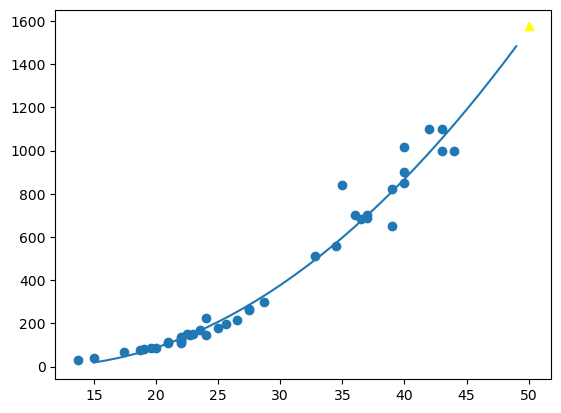

In [42]:
# 훈련세트의 산점도
plt.Figure(figsize=(10, 5))

plt.scatter(
    train_input,
    train_target
)
# 길이가 15 ~ 50cm 까지 1차방정식 그래프
point = np.arange(15, 50)
plt.plot(
    point,
    1.01*point**2 -21.6*point + 116.05
)
# 50cm 생선
plt.scatter(
    50,
    1574,
    marker='^',
    c='yellow'
)

plt.show()